In [1]:
import os
import pandas as pd
import numpy as np
import datetime as dt
import pickle
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

# silence warnings
import warnings
warnings.filterwarnings('ignore')

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2024-12-16 21:15:20.126021


#### Functions

In [3]:
def age_tag(flt_age):
    if flt_age >= 60:
        return 1
    else:
        return 0

#### Constants

In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

int_n_iterations = 100
int_n_early_stopping = 5

Project: 20241112-simple-model-test
Task: 09_15_in_60


#### Make output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import model

In [6]:
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'../02_model/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)
list_cols_model = [col.split('_binned')[0] for col in list_cols_model]
print(f'There are {len(list_cols_model)} features in the model')

There are 25 features in the model


#### Import data

In [7]:
# get cols to import
list_cols_id = [
    'accountid',
    'request_datetime',
    'bitdebtor',
    'subjectage__ln',
]
list_cols_import = list_cols_id + list_cols_model
# import
str_filename_tmp = 'df.gzip'
str_uri = f's3://{str_project}/08_prep_data/{str_filename_tmp}'
df = pd.read_parquet(
    str_uri,
    columns=list_cols_import,
)
# clean up subject age
df['subjectage__ln'] = df['subjectage__ln'].mask(df['subjectage__ln'] < 0, np.nan)
flt_mdn = df['subjectage__ln'].median()
print(f'Missing age imputed with {flt_mdn:0.2f}')
df['subjectage__ln'] = df['subjectage__ln'].fillna(flt_mdn)
# create tag
df['tag_age'] = df['subjectage__ln'].apply(age_tag)
# show
df

Missing age imputed with 42.00


,accountid,request_datetime,bitdebtor,subjectage__ln,dti__app,bkc321__tu,cv15__tu,balmag01__tu,flt_mean_months_to_first_bad__tu_pmthx,linka006__tu,...,inquiryshortterm12month__ln,addrinputtimenewest__ln,s064b__tu,fltgrossmonthly__income_sum,flt_wtd_avg_closed__tu_pmthx,ENG-has_codebtor,paymnt11__tu,g106s__tu,miles_odometer__app,tag_age
37865,5514485,2022-10-15 02:35:52.2455863,1,48.0,0.307483,NaN,2.0,231.0,1.000000,2.0,...,0.0,NaN,NaN,3976.0,NaN,0,3.0,351.0,44878.0,0
37866,5514970,2022-10-15 02:36:32.6396499,1,32.0,0.391327,NaN,1.0,180.0,0.333333,2.0,...,0.0,1.0,3961.0,5720.0,NaN,0,31.0,118.0,26828.0,0
37869,5515245,2022-10-15 02:36:53.5525392,1,34.0,0.233488,NaN,1.0,164.0,0.035714,12.0,...,0.0,1.0,1808.0,4823.0,0.224138,0,11.0,195.0,1456.0,0
37870,5515340,2022-10-15 02:37:13.5377961,1,46.0,0.500825,NaN,1.0,267.0,0.000000,3.0,...,0.0,29.0,NaN,4160.0,NaN,0,NaN,277.0,83463.0,0
37871,5515580,2022-10-15 02:37:34.1144830,0,32.0,0.321183,NaN,1.0,NaN,1.000000,NaN,...,0.0,35.0,180.0,2357.0,1.000000,1,NaN,160.0,24384.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94427,8420461,2024-11-26 02:27:09+00:00,1,43.0,0.299721,32.0,2.0,313.0,0.041667,12.0,...,1.0,1.0,2899.0,6046.0,0.366667,0,15.0,264.0,61431.0,0
94474,8420588,2024-11-26 06:16:16+00:00,1,41.0,0.319642,NaN,3.0,436.0,0.012987,13.0,...,0.0,1.0,5848.0,8086.0,0.177156,0,7.0,268.0,27622.0,0
94428,8420665,2024-11-26 02:37:11+00:00,1,47.0,0.352242,NaN,2.0,NaN,0.135024,2.0,...,0.0,NaN,NaN,3951.0,0.833333,0,NaN,339.0,23845.0,0
94458,8421889,2024-11-26 05:10:18+00:00,1,42.0,0.484241,NaN,2.0,242.0,0.514286,6.0,...,1.0,1.0,8789.0,4117.0,1.000000,0,13.0,61.0,17.0,0


#### Impute

In [8]:
str_filename = 'dict_impute.pkl'
str_local_path = f'../02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

# impute
for key, val in tqdm(dict_impute.items()):
    try:
        df[key] = df[key].fillna(val)
    except KeyError:
        pass

100%|██████████| 50/50 [00:00<00:00, 1848.04it/s]


#### Get targets

In [9]:
str_filename = 'df.gzip'
str_local_path = f'../../disparate_targets/output/{str_filename}'
df_tmp = pd.read_parquet(str_local_path)
# show
df_tmp

,bigAccountId,bigDebtorId,bitDebtor,strNameFirst,strNameLast,strZipCode,max_proba_race,race,gender
index,,,,,,,,,
0,6892112,8599253,1,MICHAEL,FOWLER,20772,0.535669,black,male
1,6892117,8599258,1,AARON,URRUTIA,46902,0.793034,white,male
2,6892119,8599260,1,GERALD,CLEMONT,95824,NaN,None,male
3,6892126,8599267,1,JORDAN,BYRD,36532,0.969298,white,male
4,6892127,8599269,1,DAVID,WILSON,47993,0.996891,white,male
...,...,...,...,...,...,...,...,...,...
3162933,7998486,9907866,1,ANTHONY,BUSCHBAUM,86314,NaN,None,male
3162934,7998487,9907867,1,JUSTIN,EVANS,90001,NaN,None,male
3162936,7998488,9907869,1,AMANDA,FEDERICI,18020,NaN,None,female


#### Join

In [10]:
df = pd.merge(
    left=df,
    right=df_tmp,
    left_on=['accountid', 'bitdebtor'],
    right_on=['bigAccountId', 'bitDebtor'],
    how='inner',
)
del df_tmp
# show
df

,accountid,request_datetime,bitdebtor,subjectage__ln,dti__app,bkc321__tu,cv15__tu,balmag01__tu,flt_mean_months_to_first_bad__tu_pmthx,linka006__tu,...,tag_age,bigAccountId,bigDebtorId,bitDebtor,strNameFirst,strNameLast,strZipCode,max_proba_race,race,gender
0,5514485,2022-10-15 02:35:52.2455863,1,48.0,0.307483,0.0,2.0,231.0,1.000000,2.0,...,0,5514485,6937315,1,JEFFREY,GRACE,22851,0.941544,white,male
1,5514970,2022-10-15 02:36:32.6396499,1,32.0,0.391327,0.0,1.0,180.0,0.333333,2.0,...,0,5514970,6937905,1,JOSHUA,JENKINS,95973,0.956905,white,male
2,5515245,2022-10-15 02:36:53.5525392,1,34.0,0.233488,0.0,1.0,164.0,0.035714,12.0,...,0,5515245,6938233,1,JEREMY,FARRAR,78727,0.938962,white,male
3,5515580,2022-10-15 02:37:34.1144830,0,32.0,0.321183,0.0,1.0,600.0,1.000000,162.0,...,0,5515580,6938635,0,MARCUS,OTT,40741,0.866431,white,male
4,5515580,2022-10-15 02:37:34.1144830,1,33.0,0.321183,0.0,2.0,600.0,0.000000,2.0,...,0,5515580,6938634,1,BRANDY,SPAULDING,40741,0.907407,white,female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76008,8420084,2024-11-26 03:18:22+00:00,1,32.0,0.352039,0.0,2.0,302.0,0.506098,22.0,...,0,8420084,10396391,1,CANDICE,ELLIOTT,45240,0.899406,white,female
76009,8420216,2024-11-26 04:59:34+00:00,1,71.0,0.227566,29.0,1.0,272.0,1.000000,162.0,...,1,8420216,10396557,1,RAUL,MORENO,33016,0.981367,hispanic,male
76010,8420588,2024-11-26 06:16:16+00:00,1,41.0,0.319642,0.0,3.0,436.0,0.012987,13.0,...,0,8420588,10397012,1,COURTNEY,GAYLOR,27597,0.673280,black,female
76011,8421889,2024-11-26 05:10:18+00:00,1,42.0,0.484241,0.0,2.0,242.0,0.514286,6.0,...,0,8421889,10398666,1,RYAN,LIMORAN,30052,NaN,None,male


#### Race

In [11]:
# make copy
df_tmp = df.copy()
# subset
df_tmp = df_tmp[df_tmp['max_proba_race'] >= 0.70].copy()

# make mapping dictionary for target
dict_map = {
    'white': 0,
    'black': 1,
    'hispanic': 2,
    'native': 3,
    'api': 4,
    'multiple': 5,
}
df_tmp['target'] = df_tmp['race'].map(dict_map)

# X, y split
X = df_tmp[list_cols_model].copy()
y = df_tmp['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.25,
    shuffle=True,
)

# pool train
pool_train = cb.Pool(
    X_train,
    y_train,
)
del X_train, y_train

# pool test
pool_test = cb.Pool(
    X_test,
    y_test,
)
del X_test, y_test

# init
cls_model_inference_tmp = cb.CatBoostClassifier(
    task_type='CPU',
    nan_mode='Min',
    random_state=42,
    eval_metric='MultiClass',
    iterations=int_n_iterations,
)
# fit
cls_model_inference_tmp.fit(
    pool_train,
    eval_set=[pool_test],
    verbose=10,
    use_best_model=True,
    early_stopping_rounds=int_n_early_stopping,
)
# get feat imp
df_race = pd.DataFrame({
    'feature': cls_model_inference_tmp.feature_names_,
    'importance': cls_model_inference_tmp.feature_importances_,
})
df_race.sort_values(by='importance', ascending=False, inplace=True)
# rank
df_race['rank'] = list(range(1, df_race.shape[0]+1))

# save
str_filename = 'df_race.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_race.to_csv(str_local_path, index=False)

# dictionary
dict_race = dict(zip(df_race['feature'], df_race['rank']))

# show
df_race

Learning rate set to 0.279877
0:	learn: 1.2570306	test: 1.2598946	best: 1.2598946 (0)	total: 64.4ms	remaining: 6.38s
10:	learn: 0.8159642	test: 0.8248673	best: 0.8248673 (10)	total: 200ms	remaining: 1.61s
20:	learn: 0.7944931	test: 0.8115789	best: 0.8115789 (20)	total: 337ms	remaining: 1.27s
Stopped by overfitting detector  (5 iterations wait)

bestTest = 0.8107991576
bestIteration = 23

Shrink model to first 24 iterations.


,feature,importance,rank
23,g106s__tu,15.980634,1
8,derogseverityindex__ln,9.798735,2
4,flt_mean_months_to_first_bad__tu_pmthx,8.994631,3
0,dti__app,5.935715,4
18,s064b__tu,5.255666,5
9,at21s__tu,5.016890,6
24,miles_odometer__app,4.833207,7
22,paymnt11__tu,4.408141,8
13,ENG-loan_to_value,3.927420,9
19,fltgrossmonthly__income_sum,3.855754,10


#### Gender

In [12]:
# make copy
df_tmp = df.copy()

# make mapping dictionary
dict_map = {
    'male': 0,
    'female': 1,
}
df_tmp['target'] = df_tmp['gender'].map(dict_map)

# X, y split
X = df_tmp[list_cols_model].copy()
y = df_tmp['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.25,
    shuffle=True,
)

# pool train
pool_train = cb.Pool(
    X_train,
    y_train,
)
del X_train, y_train

# pool test
pool_test = cb.Pool(
    X_test,
    y_test,
)
del X_test, y_test

# init
cls_model_inference_tmp = cb.CatBoostClassifier(
    task_type='CPU',
    nan_mode='Min',
    random_state=42,
    eval_metric='AUC',
    iterations=int_n_iterations,
)
# fit
cls_model_inference_tmp.fit(
    pool_train,
    eval_set=[pool_test],
    verbose=10,
    use_best_model=True,
    early_stopping_rounds=int_n_early_stopping,
)
# get feat imp
df_gender = pd.DataFrame({
    'feature': cls_model_inference_tmp.feature_names_,
    'importance': cls_model_inference_tmp.feature_importances_,
})
df_gender.sort_values(by='importance', ascending=False, inplace=True)
# rank
df_gender['rank'] = list(range(1, df_gender.shape[0]+1))

# save
str_filename = 'df_gender.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_gender.to_csv(str_local_path, index=False)

# dictionary
dict_gender = dict(zip(df_gender['feature'], df_gender['rank']))

# show
df_gender

Learning rate set to 0.234222
0:	test: 0.6305244	best: 0.6305244 (0)	total: 9.03ms	remaining: 894ms
10:	test: 0.6654263	best: 0.6654263 (10)	total: 91.8ms	remaining: 742ms
20:	test: 0.6714037	best: 0.6714037 (20)	total: 176ms	remaining: 661ms
30:	test: 0.6739311	best: 0.6739311 (30)	total: 261ms	remaining: 581ms
40:	test: 0.6773442	best: 0.6773442 (40)	total: 347ms	remaining: 499ms
50:	test: 0.6792036	best: 0.6792036 (50)	total: 430ms	remaining: 413ms
60:	test: 0.6801486	best: 0.6801486 (60)	total: 515ms	remaining: 329ms
Stopped by overfitting detector  (5 iterations wait)

bestTest = 0.6808651875
bestIteration = 63

Shrink model to first 64 iterations.


,feature,importance,rank
19,fltgrossmonthly__income_sum,23.840061,1
6,re01s__tu,10.870569,2
23,g106s__tu,10.237789,3
8,derogseverityindex__ln,8.406582,4
24,miles_odometer__app,5.230348,5
21,ENG-has_codebtor,4.480586,6
0,dti__app,3.939365,7
4,flt_mean_months_to_first_bad__tu_pmthx,3.614993,8
2,cv15__tu,3.187003,9
7,flt_avg_open__tu_pmthx,3.125363,10


#### Age

In [13]:
# make copy
df_tmp = df.copy()

# create target
df_tmp['target'] = df_tmp['tag_age']

# X, y split
X = df_tmp[list_cols_model].copy()
y = df_tmp['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.25,
    shuffle=True,
)

# pool train
pool_train = cb.Pool(
    X_train,
    y_train,
)
del X_train, y_train

# pool test
pool_test = cb.Pool(
    X_test,
    y_test,
)
del X_test, y_test

# init
cls_model_inference_tmp = cb.CatBoostClassifier(
    task_type='CPU',
    nan_mode='Min',
    random_state=42,
    eval_metric='AUC',
    iterations=int_n_iterations,
)
# fit
cls_model_inference_tmp.fit(
    pool_train,
    eval_set=[pool_test],
    verbose=10,
    use_best_model=True,
    early_stopping_rounds=int_n_early_stopping,
)
# get feat imp
df_age = pd.DataFrame({
    'feature': cls_model_inference_tmp.feature_names_,
    'importance': cls_model_inference_tmp.feature_importances_,
})
df_age.sort_values(by='importance', ascending=False, inplace=True)
# rank
df_age['rank'] = list(range(1, df_age.shape[0]+1))

# save
str_filename = 'df_age.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_age.to_csv(str_local_path, index=False)

# dictionary
dict_age = dict(zip(df_age['feature'], df_age['rank']))

# show
df_age

Learning rate set to 0.234222
0:	test: 0.8951503	best: 0.8951503 (0)	total: 8.37ms	remaining: 829ms
10:	test: 0.9194560	best: 0.9194560 (10)	total: 89.1ms	remaining: 721ms
20:	test: 0.9223032	best: 0.9223032 (20)	total: 173ms	remaining: 649ms
Stopped by overfitting detector  (5 iterations wait)

bestTest = 0.9226134977
bestIteration = 23

Shrink model to first 24 iterations.


,feature,importance,rank
23,g106s__tu,59.661378,1
19,fltgrossmonthly__income_sum,8.144368,2
8,derogseverityindex__ln,5.213399,3
3,balmag01__tu,3.361650,4
14,inquirybanking12month__ln,2.973125,5
15,linka017__tu,2.826581,6
5,linka006__tu,2.209066,7
0,dti__app,1.849920,8
9,at21s__tu,1.756051,9
7,flt_avg_open__tu_pmthx,1.484807,10


#### Map

In [14]:
df = df_race.copy()

# drop
df.drop('importance', axis=1, inplace=True)

# rename
dict_rename = {
    'rank': 'rank_race',
}
df.rename(columns=dict_rename, inplace=True)

# map age
df['rank_age'] = df['feature'].map(dict_age)

# map gender
df['rank_gender'] = df['feature'].map(dict_gender)

# sum
list_cols = [
    'rank_race',
    'rank_age',
    'rank_gender',
]
df['rank_mean'] = df[list_cols].mean(axis=1)

# sort
df.sort_values(by='rank_mean', ascending=True, inplace=True)

# show
df

,feature,rank_race,rank_age,rank_gender,rank_mean
23,g106s__tu,1,1,3,1.666667
8,derogseverityindex__ln,2,3,4,3.000000
19,fltgrossmonthly__income_sum,10,2,1,4.333333
0,dti__app,4,8,7,6.333333
9,at21s__tu,6,9,11,8.666667
4,flt_mean_months_to_first_bad__tu_pmthx,3,16,8,9.000000
6,re01s__tu,15,12,2,9.666667
24,miles_odometer__app,7,20,5,10.666667
3,balmag01__tu,13,4,16,11.000000
18,s064b__tu,5,18,13,12.000000


#### Get the output from sensitivity analysis

In [15]:
str_filename = 'df_sensitivity.csv'
str_local_path = f'../02_model/output/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
# rm binned
df_tmp['feature'] = df_tmp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
# show
df_tmp

,feature,score,target,diff
0,dti__app,0.624791,0.637682,-0.012890
1,bkc321__tu,0.632832,0.637682,-0.004850
2,at21s__tu,0.634438,0.637682,-0.003244
3,balmag01__tu,0.634877,0.637682,-0.002805
4,derogseverityindex__ln,0.635333,0.637682,-0.002349
5,ENG-loan_to_value,0.636082,0.637682,-0.001600
6,inquiryshortterm12month__ln,0.636102,0.637682,-0.001580
7,g232s__tu,0.636145,0.637682,-0.001536
8,fltgrossmonthly__income_sum,0.636255,0.637682,-0.001427
9,re01s__tu,0.636420,0.637682,-0.001261


#### Join

In [16]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='feature',
    how='inner',
)
# show
df

,feature,rank_race,rank_age,rank_gender,rank_mean,score,target,diff
0,g106s__tu,1,1,3,1.666667,0.637061,0.637682,-0.000621
1,derogseverityindex__ln,2,3,4,3.000000,0.635333,0.637682,-0.002349
2,fltgrossmonthly__income_sum,10,2,1,4.333333,0.636255,0.637682,-0.001427
3,dti__app,4,8,7,6.333333,0.624791,0.637682,-0.012890
4,at21s__tu,6,9,11,8.666667,0.634438,0.637682,-0.003244
5,flt_mean_months_to_first_bad__tu_pmthx,3,16,8,9.000000,0.637257,0.637682,-0.000425
6,re01s__tu,15,12,2,9.666667,0.636420,0.637682,-0.001261
7,miles_odometer__app,7,20,5,10.666667,0.637457,0.637682,-0.000224
8,balmag01__tu,13,4,16,11.000000,0.634877,0.637682,-0.002805
9,s064b__tu,5,18,13,12.000000,0.637309,0.637682,-0.000373


#### Save

In [17]:
str_filename = 'df.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=False)

#### Plot

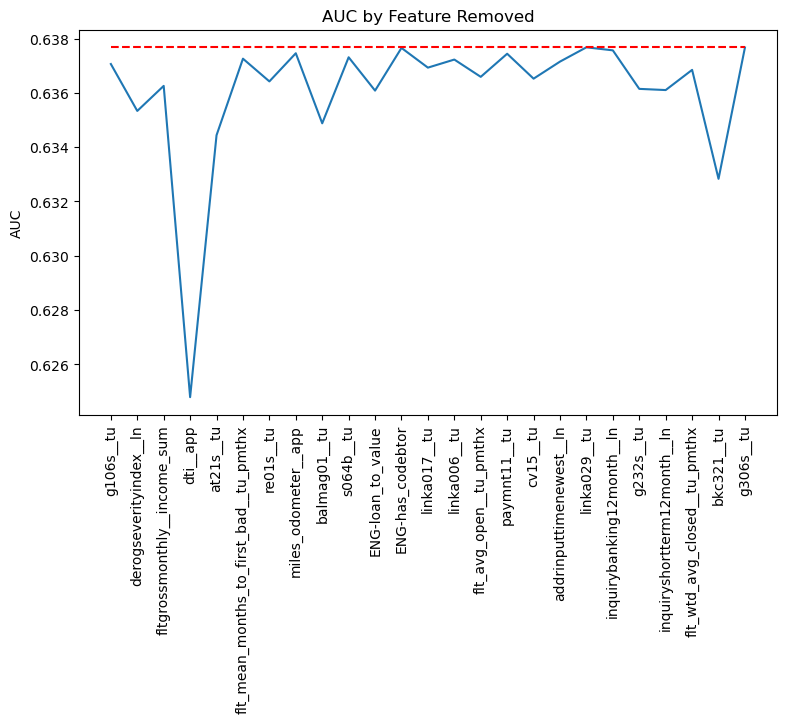

In [18]:
x = df['feature']
y = df['score']
z = df['target']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('AUC by Feature Removed')
ax.set_ylabel('AUC')
ax.plot(x, y)
ax.plot(x, z, linestyle='--', color='red')
ax.set_xticklabels(x, rotation=90)
plt.show()